# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: 06

Group Members:
- Richard Christian 13523024
- Kenneth Poenadi Name 13523040
- Ivan Wirawan 13523046
- Bob Kunanda 13523086
- M Zahran Ramadhan 13523104

## Import Libraries

In [1]:
# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, Normalizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import BaseEstimator, TransformerMixin

# Imbalanced data handling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Model interpretation
import shap

# Deep learning (optional - not used for SVM)
# Uncomment if you need neural networks or autoencoders
# try:
#     import tensorflow as tf
#     from tensorflow import keras
#     from tensorflow.keras import layers
#     KERAS_AVAILABLE = True
# except:
#     KERAS_AVAILABLE = False
#     print("Warning: TensorFlow not available. Deep learning features disabled.")

# Model persistence
import joblib
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 67

## Import Dataset

In [2]:
# Example of reading a csv file from a gdrive link

# Take the file id from the gdrive file url
# https://drive.google.com/file/d/1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU/view?usp=sharing => The file id is 1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU
# and then put it in this format:
# https://drive.google.com/uc?id={file_id}
# Don't forget to change the access to public

df = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [3]:
# profile = ProfileReport(df, title="EDA Report", explorative=True)
# profile.to_notebook_iframe()


In [4]:
categorical_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance\t', 'Previous qualification',  'Gender', 'Nacionality', 
    'Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation', 'Father\'s occupation',
    'Educational special needs', 'International',
    'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Displaced'
]

df[categorical_cols] = df[categorical_cols].astype(str)
df_test[categorical_cols] = df_test[categorical_cols].astype(str)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3096 entries, 0 to 3095
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      3096 non-null   int64  
 1   Marital status                                  3096 non-null   object 
 2   Application mode                                3096 non-null   object 
 3   Application order                               3096 non-null   object 
 4   Course                                          3096 non-null   object 
 5   Daytime/evening attendance	                     3096 non-null   object 
 6   Previous qualification                          3096 non-null   object 
 7   Previous qualification (grade)                  3096 non-null   float64
 8   Nacionality                                     3096 non-null   object 
 9   Mother's qualification                   

In [5]:
def top3_categories_per_target(df, target_col="Target"):
    """
    For every categorical column in df (except the target),
    prints the top 3 most frequent categories per target class.
    """
    df = df.copy()

    # Identify categorical columns
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    # Remove target from list
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)

    print("===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====\n")

    for col in categorical_cols:
        print(f"\n--- Column: {col} ---")

        # Group by target and category count
        grouped = df.groupby([target_col, col]).size().reset_index(name="count")

        # For each target label, show top 3
        for target_value in df[target_col].unique():
            subset = grouped[grouped[target_col] == target_value].sort_values("count", ascending=False).head(3)

            print(f"\nTarget = {target_value}:")
            if subset.empty:
                print("  (No data)")
            else:
                for _, row in subset.iterrows():
                    print(f"  {row[col]} → {row['count']} times")


# Run it
top3_categories_per_target(df)

===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====


--- Column: Marital status ---

Target = Graduate:
  1 → 1415 times
  2 → 102 times
  4 → 23 times

Target = Dropout:
  1 → 830 times
  2 → 127 times
  4 → 29 times

Target = Enrolled:
  1 → 513 times
  2 → 30 times
  4 → 10 times

--- Column: Application mode ---

Target = Graduate:
  1 → 765 times
  17 → 310 times
  39 → 151 times

Target = Dropout:
  39 → 308 times
  1 → 238 times
  17 → 184 times

Target = Enrolled:
  1 → 215 times
  17 → 115 times
  39 → 79 times

--- Column: Application order ---

Target = Graduate:
  1 → 979 times
  2 → 212 times
  3 → 123 times

Target = Dropout:
  1 → 738 times
  2 → 109 times
  3 → 52 times

Target = Enrolled:
  1 → 398 times
  2 → 67 times
  3 → 47 times

--- Column: Course ---

Target = Graduate:
  9500 → 373 times
  9238 → 181 times
  9773 → 134 times

Target = Dropout:
  9991 → 101 times
  9147 → 93 times
  9500 → 77 times

Target = Enrolled:
  9147 → 80 times
  9500 → 73 times
  9085 →

In [6]:
df.skew(numeric_only=True)


Student_ID                                        0.009088
Previous qualification (grade)                    0.299831
Admission grade                                   0.529363
Age at enrollment                                 2.081474
Curricular units 1st sem (credited)               4.188695
Curricular units 1st sem (enrolled)               1.588180
Curricular units 1st sem (evaluations)            0.886651
Curricular units 1st sem (approved)               0.772061
Curricular units 1st sem (grade)                 -1.548017
Curricular units 1st sem (without evaluations)    7.748450
Curricular units 2nd sem (credited)               4.647403
Curricular units 2nd sem (enrolled)               0.713280
Curricular units 2nd sem (evaluations)            0.334332
Curricular units 2nd sem (approved)               0.299546
Curricular units 2nd sem (grade)                 -1.283620
Curricular units 2nd sem (without evaluations)    7.767834
Unemployment rate                                 0.2125

### Skewness Analysis and Correction

Skewness measures the asymmetry of a distribution. Features with high skewness can negatively impact model performance, especially for algorithms that assume normally distributed data (like Logistic Regression, SVM, and Linear models).

**Skewness values:**
- **-0.5 to 0.5**: Fairly symmetric (no transformation needed)
- **0.5 to 1** or **-1 to -0.5**: Moderately skewed (consider transformation)
- **> 1** or **< -1**: Highly skewed (transformation recommended)

**Common transformations:**
- **Log transformation**: For right-skewed data (positive skew)
- **Square root**: For moderate right skew
- **Box-Cox**: Automatic optimal transformation
- **Yeo-Johnson**: Like Box-Cox but handles zero and negative values

In [7]:
# ==================== SKEWNESS CORRECTION ====================
from sklearn.preprocessing import PowerTransformer

# Create a copy to apply transformations
def skewness_correction(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove target and ID if present
    numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]

    # Calculate skewness
    skewness = df[numerical_cols].skew().sort_values(ascending=False)

    df_transformed = df.copy()

    # Apply Yeo-Johnson transformation to highly and moderately skewed features
    skewed_features = skewness[abs(skewness) > 0.5].index.tolist()

    print(f"\nApplying Yeo-Johnson transformation to {len(skewed_features)} skewed features...")

    if len(skewed_features) > 0:
        # Yeo-Johnson works with positive, zero, and negative values
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        
        # Transform only the skewed features
        df_transformed[skewed_features] = pt.fit_transform(df[skewed_features])
        
        # Calculate new skewness
        new_skewness = df_transformed[skewed_features].skew().sort_values(ascending=False)
        
        # Compare before and after
        comparison = pd.DataFrame({
            'Before': skewness[skewed_features],
            'After': new_skewness,
            'Improvement': abs(skewness[skewed_features]) - abs(new_skewness)
        }).sort_values('Before', ascending=False)
        
       
        return df_transformed
    else:
        print("No skewed features found!")



### Skewness Transformer Class (for Pipeline)

You can use this class in your sklearn Pipeline to automatically detect and fix skewness during preprocessing.

In [8]:
class SkewnessTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to fix skewness in numerical features using Yeo-Johnson transformation.
    
    Parameters:
    -----------
    skew_threshold : float
        Absolute skewness threshold above which transformation is applied (default: 0.5)
    method : str
        Transformation method: 'yeo-johnson' or 'box-cox' (default: 'yeo-johnson')
        Note: box-cox only works with positive values, yeo-johnson works with any values
    """
    
    def __init__(self, skew_threshold=0.5, method='yeo-johnson'):
        self.skew_threshold = skew_threshold
        self.method = method
        self.transformer = None
        self.skewed_features = []
        self.original_skewness = {}
        self.transformed_skewness = {}
        
    def fit(self, X, y=None):
        """Identify skewed features and fit transformer"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Calculate skewness for numerical columns
        skewness = X_df.select_dtypes(include=[np.number]).skew()
        
        # Identify features above threshold
        self.skewed_features = skewness[abs(skewness) > self.skew_threshold].index.tolist()
        self.original_skewness = skewness[self.skewed_features].to_dict()
        
        if len(self.skewed_features) > 0:
            print(f"SkewnessTransformer: Found {len(self.skewed_features)} skewed features (|skew| > {self.skew_threshold})")
            
            # Fit transformer on skewed features
            self.transformer = PowerTransformer(method=self.method, standardize=False)
            self.transformer.fit(X_df[self.skewed_features])
        else:
            print(f"SkewnessTransformer: No skewed features found (threshold={self.skew_threshold})")
        
        return self
    
    def transform(self, X):
        """Apply transformation to skewed features"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        if len(self.skewed_features) > 0 and self.transformer is not None:
            # Transform only the skewed features
            X_df[self.skewed_features] = self.transformer.transform(X_df[self.skewed_features])
        
        return X_df if isinstance(X, pd.DataFrame) else X_df.values
    
    def get_skewness_report(self):
        """Get before/after skewness comparison"""
        if len(self.skewed_features) == 0:
            return "No skewed features found."
        
        report = pd.DataFrame({
            'Feature': self.skewed_features,
            'Original_Skewness': [self.original_skewness[f] for f in self.skewed_features],
            'Transformed_Skewness': [self.transformed_skewness.get(f, 0) for f in self.skewed_features]
        })
        return report


# # Example usage in a pipeline:
# from sklearn.pipeline import Pipeline

# pipe = Pipeline([
#     ('skewness_fix', SkewnessTransformer(skew_threshold=0.5)),
#     ('scaler', StandardScaler()),
#     ('model', LogisticRegression())
# ])

# pipe.fit(X_train, y_train)
# predictions = pipe.predict(X_test)

# 1. Split Training Set and Validation Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [9]:
# Split training set and validation set here, store into variables train_set and val_set.
# Remember to also keep the original training set before splitting. This will come important later.
# train_set, val_set = ...

# pake k-fold cross validatoin aja




# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [10]:
# Write your code here

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [11]:
# ==================== DATA CLEANING ====================
df = df.drop_duplicates()
print(f"Rows after duplicate removal: {df.shape[0]}")

Rows after duplicate removal: 3096


In [12]:
# Write your code here

### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [13]:
# ==================== SAFE FEATURE ENGINEERING (HANDLES DIVISION BY ZERO) ====================
import numpy as np
import pandas as pd

def add_features(df):
    """
    Add engineered features with proper handling of division by zero and NaN values.
    Returns a copy of the dataframe with new features.
    """
    df = df.copy()
    
    # Age grouping - convert to numeric immediately
    df["Age_Group"] = pd.cut(
        df["Age at enrollment"],
        bins=[0, 18, 20, 25, 100],
        labels=[1, 2, 3, 4],
        right=True
    ).astype(float)  # Convert to float to avoid categorical dtype issues

    # Semester 1 - Safe division with np.where
    df["S1_Pass_Rate"] = np.where(
        df["Curricular units 1st sem (enrolled)"] > 0,
        df["Curricular units 1st sem (approved)"] / df["Curricular units 1st sem (enrolled)"],
        0.0  # Default to 0 if not enrolled
    )

    df["S1_Evaluation_Attendance_Rate"] = np.where(
        df["Curricular units 1st sem (enrolled)"] > 0,
        df["Curricular units 1st sem (evaluations)"] / df["Curricular units 1st sem (enrolled)"],
        0.0
    )

    df["S1_Avoidance_Rate"] = 1.0 - df["S1_Evaluation_Attendance_Rate"]

    # Semester 2 - Safe division
    df["S2_Pass_Rate"] = np.where(
        df["Curricular units 2nd sem (enrolled)"] > 0,
        df["Curricular units 2nd sem (approved)"] / df["Curricular units 2nd sem (enrolled)"],
        0.0
    )

    df["S2_Evaluation_Attendance_Rate"] = np.where(
        df["Curricular units 2nd sem (enrolled)"] > 0,
        df["Curricular units 2nd sem (evaluations)"] / df["Curricular units 2nd sem (enrolled)"],
        0.0
    )

    df["S2_Avoidance_Rate"] = 1.0 - df["S2_Evaluation_Attendance_Rate"]

    # Progress Metrics
    df["Pass_rate_progress"] = df["S2_Pass_Rate"] - df["S1_Pass_Rate"]
    df["Grade_progress"] = df["Curricular units 2nd sem (grade)"] - df["Curricular units 1st sem (grade)"]
    df["Attendance_progress"] = df["S2_Evaluation_Attendance_Rate"] - df["S1_Evaluation_Attendance_Rate"]
    df["Avoidance_progress"] = df["S2_Avoidance_Rate"] - df["S1_Avoidance_Rate"]
    
    # Replace any remaining inf or nan values with 0
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    return df

# Apply feature engineering
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)
print(f"Original features: {df.shape[1]}")



print(f"After feature engineering: {df.shape[1]}")
print(f"New features added: {df.shape[1] - len(df.columns) + 13}")  # Approximate

# Verify no NaN or inf values
numeric_cols = df.select_dtypes(include=[np.number]).columns
nan_count = df[numeric_cols].isna().sum().sum()
inf_count = np.isinf(df[numeric_cols]).sum().sum()

print(f"\n✓ Quality check:")
print(f"  NaN values: {nan_count}")
print(f"  Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("  ⚠️ Warning: Found NaN or Inf values, filling with 0...")
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    df[numeric_cols] = df[numeric_cols].fillna(0)
    print("  ✓ Fixed!")
else:
    print("  ✓ All values are valid!")

FEATURE ENGINEERING
Original features: 38
After feature engineering: 38
New features added: 13

✓ Quality check:
  NaN values: 0
  Inf values: 0
  ✓ All values are valid!


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [14]:
# Example

# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEncoder(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):

#         # Fit the encoder here

#         return self

#     def transform(self, X):
#         X_encoded = X.copy()

#         # Encode the categorical variables here

#         return X_encoded

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [15]:
# ==================== MIN-MAX NORMALIZATION (0-1 RANGE) ====================
from sklearn.preprocessing import MinMaxScaler

def min_max_normalization(df):
    """
    Apply Min-Max Normalization to numerical features in the dataframe.
    Returns a copy of the dataframe with normalized features.
    """
    df = df.copy()
    
    # Identify numerical columns (exclude categorical and target)
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]
    
    print(f"\nApplying Min-Max Normalization to {len(numerical_cols)} numerical features...")
    
    # Create MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # Apply normalization
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    
    return df
# Identify numerical columns (exclude categorical, target, and ID)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]

print("="*60)
print("MIN-MAX NORMALIZATION (0-1 RANGE)")
print("="*60)
print(f"Normalizing {len(numerical_cols)} numerical features...")

# Create MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply normalization
df = df.copy()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\n✓ Normalization complete!")
print(f"\nBefore normalization:")
print(df[numerical_cols].describe().loc[['min', 'max']])
print(f"\nAfter normalization:")
print(df[numerical_cols].describe().loc[['min', 'max']])


MIN-MAX NORMALIZATION (0-1 RANGE)
Normalizing 18 numerical features...

✓ Normalization complete!

Before normalization:
     Previous qualification (grade)  Admission grade  Age at enrollment  \
min                             0.0              0.0                0.0   
max                             1.0              1.0                1.0   

     Curricular units 1st sem (credited)  Curricular units 1st sem (enrolled)  \
min                                  0.0                                  0.0   
max                                  1.0                                  1.0   

     Curricular units 1st sem (evaluations)  \
min                                     0.0   
max                                     1.0   

     Curricular units 1st sem (approved)  Curricular units 1st sem (grade)  \
min                                  0.0                               0.0   
max                                  1.0                               1.0   

     Curricular units 1st sem (w

### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [16]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_fit_transform(df):
    """
    Fit OneHotEncoder on df and transform df.
    Returns encoded_df and encoder.
    """
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    categorical_cols = [col for col in categorical_cols if col not in ['Target', 'Student_ID']]

    encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore',
        drop='first'
    )

    encoded_array = encoder.fit_transform(df[categorical_cols])
    encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    return df, encoder
def one_hot_transform(df, encoder):
    df = df.copy()
    categorical_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns
                        if col not in ['Target', 'Student_ID']]

    encoded_array = encoder.transform(df[categorical_cols])
    encoded_feature_names = encoder.get_feature_names_out()

    df_encoded = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    return df


In [17]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      1328 non-null   int64  
 1   Marital status                                  1328 non-null   object 
 2   Application mode                                1328 non-null   object 
 3   Application order                               1328 non-null   object 
 4   Course                                          1328 non-null   object 
 5   Daytime/evening attendance	                     1328 non-null   object 
 6   Previous qualification                          1328 non-null   object 
 7   Previous qualification (grade)                  1328 non-null   float64
 8   Nacionality                                     1328 non-null   object 
 9   Mother's qualification                   

### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [18]:
from imblearn.over_sampling import SMOTE, RandomOverSampler

def oversample_targets(df, target_col='Target', id_col='Student_ID', random_state=42):
    """
    Oversamples minority classes using SMOTE.
    If SMOTE fails, fallback to RandomOverSampler.
    
    Output:
        df_resampled (DataFrame)
        method_used (string)
    """
    df = df.copy()

    # Separate X and y
    if id_col in df.columns:
        X = df.drop(columns=[target_col, id_col])
    else:
        X = df.drop(columns=[target_col])
    y = df[target_col]

    class_counts = y.value_counts()
    max_count = class_counts.max()

    # Strategy: oversample all minority classes to match the majority
    sampling_strategy = {cls: max_count for cls in class_counts.index}

    # Try SMOTE
    smote = SMOTE(sampling_strategy=sampling_strategy, 
                  random_state=random_state, 
                  k_neighbors=5)

    try:
        X_resampled, y_resampled = smote.fit_resample(X, y)
        method_used = "SMOTE"
    except Exception:
        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=random_state)
        X_resampled, y_resampled = ros.fit_resample(X, y)
        method_used = "RandomOverSampler"
    
    # Build new balanced DataFrame
    df_resampled = pd.concat([
        X_resampled.reset_index(drop=True),
        pd.Series(y_resampled, name=target_col)
    ], axis=1)

    return df_resampled


### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [19]:
# Write your code here

### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [20]:
# Write your code here

# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [21]:
# from sklearn.pipeline import Pipeline

# # Note: You can add or delete preprocessing components from this pipeline

# pipe = Pipeline([("imputer", FeatureImputer()),
#                  ("featurecreator", FeatureCreator()),
#                  ("scaler", FeatureScaler()),
#                  ("encoder", FeatureEncoder())])

# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

In [22]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

or create your own here

In [23]:
# ==================== COMPLETE PREPROCESSING PIPELINE WITH FIT/TRANSFORM ====================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

class PreprocessingPipeline(BaseEstimator, TransformerMixin):
    """
    Complete preprocessing pipeline that properly applies fit/transform pattern.
    
    Steps:
    1. Min-Max normalization (0-1 range) for numerical features
    2. One-hot encoding for categorical features  
    3. Oversampling for Dropout and Enrolled (only during fit, not transform)
    
    Usage:
        # Initialize
        preprocessor = PreprocessingPipeline(apply_oversampling=True)
        
        # For training data (fit and optionally oversample)
        X_train_processed, y_train_processed = preprocessor.fit_transform_with_target(X_train, y_train)
        
        # For test data (only transform, no oversampling)
        X_test_processed = preprocessor.transform(X_test)
    """
    
    def __init__(self, apply_oversampling=True):
        self.apply_oversampling = apply_oversampling
        self.numerical_cols = []
        self.categorical_cols = []
        self.column_transformer = None
        self.feature_names_out = []
        self.smote = None
        
    def fit(self, X, y=None):
        """Fit the preprocessing pipeline on training data"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Ensure all categorical columns are string type (not 'category' dtype)
        for col in X_df.select_dtypes(include=['category']).columns:
            X_df[col] = X_df[col].astype(str)
        
        # Identify column types (exclude Target and Student_ID)
        self.numerical_cols = [col for col in X_df.select_dtypes(include=[np.number]).columns 
                               if col not in ['Target', 'Student_ID']]
        self.categorical_cols = [col for col in X_df.select_dtypes(include=['object']).columns 
                                 if col not in ['Target', 'Student_ID']]
        
        print("="*60)
        print("FITTING PREPROCESSING PIPELINE")
        print("="*60)
        print(f"Numerical features: {len(self.numerical_cols)}")
        print(f"Categorical features: {len(self.categorical_cols)}")
        if self.categorical_cols:
            print(f"  Categorical: {self.categorical_cols}")
        
        # Create ColumnTransformer for numerical and categorical features
        transformers = []
        
        if len(self.numerical_cols) > 0:
            transformers.append(('num', MinMaxScaler(feature_range=(0, 1)), self.numerical_cols))
        
        if len(self.categorical_cols) > 0:
            transformers.append(('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), 
                               self.categorical_cols))
        
        self.column_transformer = ColumnTransformer(transformers=transformers, remainder='passthrough')
        
        # Fit the transformer
        self.column_transformer.fit(X_df)
        
        # Get feature names
        self.feature_names_out = self._get_feature_names()
        
        print(f"✓ Fitted transformers")
        print(f"  Output features: {len(self.feature_names_out)}")
        
        # Setup SMOTE if oversampling is enabled and target is provided
        if self.apply_oversampling and y is not None:
            class_counts = pd.Series(y).value_counts()
            max_count = class_counts.max()
            
            # Oversample Dropout and Enrolled to match majority
            sampling_strategy = {}
            for cls in ['Dropout', 'Enrolled']:
                if cls in class_counts.index and class_counts[cls] < max_count:
                    sampling_strategy[cls] = max_count
            
            if sampling_strategy:
                self.smote = SMOTE(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE, k_neighbors=5)
                print(f"✓ SMOTE configured: {sampling_strategy}")
        
        return self
    
    def transform(self, X):
        """Transform features (NO oversampling - use for test data)"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Ensure categorical columns match training dtype (convert category to string)
        for col in self.categorical_cols:
            if col in X_df.columns:
                if X_df[col].dtype.name == 'category':
                    X_df[col] = X_df[col].astype(str)
                # Ensure it's object type
                if X_df[col].dtype != 'object':
                    X_df[col] = X_df[col].astype(str)
        
        # Ensure numerical columns are numeric
        for col in self.numerical_cols:
            if col in X_df.columns:
                # Fill NaN with 0 for safety
                X_df[col] = pd.to_numeric(X_df[col], errors='coerce').fillna(0)
        
        # Apply transformations
        X_transformed = self.column_transformer.transform(X_df)
        
        # Return as DataFrame with proper column names
        return pd.DataFrame(X_transformed, columns=self.feature_names_out, index=X_df.index)
    
    def fit_transform_with_target(self, X, y):
        """
        Fit and transform with oversampling (use for training data)
        
        Returns:
            X_transformed, y_transformed (both potentially oversampled)
        """
        # Fit the pipeline
        self.fit(X, y)
        
        # Transform
        X_transformed = self.transform(X)
        
        # Apply SMOTE if configured
        if self.smote is not None:
            print(f"\nApplying SMOTE oversampling...")
            X_resampled, y_resampled = self.smote.fit_resample(X_transformed, y)
            print(f"  Original: {len(y)} samples")
            print(f"  After oversampling: {len(y_resampled)} samples")
            print(f"  Class distribution:")
            print(pd.Series(y_resampled).value_counts().sort_index())
            return X_resampled, y_resampled
        else:
            return X_transformed, y
    
    def _get_feature_names(self):
        """Get feature names after transformation"""
        feature_names = []
        
        for name, transformer, columns in self.column_transformer.transformers_:
            if name == 'num':
                feature_names.extend(columns)
            elif name == 'cat':
                if hasattr(transformer, 'get_feature_names_out'):
                    feature_names.extend(transformer.get_feature_names_out(columns))
                else:
                    feature_names.extend(columns)
            elif name == 'remainder':
                # passthrough columns
                feature_names.extend([f'remainder_{i}' for i in range(len(columns))])
        
        return feature_names


# ==================== EXAMPLE USAGE ====================
print("\n" + "="*60)
print("EXAMPLE: HOW TO USE THE PIPELINE")
print("="*60)
print("""
# 1. Prepare your data
X_train = df_train.drop(columns=['Target', 'Student_ID'])
y_train = df_train['Target']
X_test = df_test.drop(columns=['Student_ID'])

# 2. Create and fit pipeline on training data
preprocessor = PreprocessingPipeline(apply_oversampling=True)
X_train_processed, y_train_processed = preprocessor.fit_transform_with_target(X_train, y_train)

# 3. Transform test data (NO oversampling)
X_test_processed = preprocessor.transform(X_test)

# 4. Train your model
model.fit(X_train_processed, y_train_processed)
predictions = model.predict(X_test_processed)

# Key points:
# - fit_transform_with_target() for TRAINING data (includes oversampling)
# - transform() for TEST data (no oversampling, uses fitted scalers/encoders)
# - This prevents data leakage!
""")


EXAMPLE: HOW TO USE THE PIPELINE

# 1. Prepare your data
X_train = df_train.drop(columns=['Target', 'Student_ID'])
y_train = df_train['Target']
X_test = df_test.drop(columns=['Student_ID'])

# 2. Create and fit pipeline on training data
preprocessor = PreprocessingPipeline(apply_oversampling=True)
X_train_processed, y_train_processed = preprocessor.fit_transform_with_target(X_train, y_train)

# 3. Transform test data (NO oversampling)
X_test_processed = preprocessor.transform(X_test)

# 4. Train your model
model.fit(X_train_processed, y_train_processed)
predictions = model.predict(X_test_processed)

# Key points:
# - fit_transform_with_target() for TRAINING data (includes oversampling)
# - transform() for TEST data (no oversampling, uses fitted scalers/encoders)
# - This prevents data leakage!



# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

## B. SVM (Support Vector Machine)

### Why SVM for This Problem?

**Support Vector Machine (SVM)** is a powerful supervised learning algorithm that works well for classification tasks, especially with the following characteristics:

1. **High-Dimensional Data**: Our dataset has many features after preprocessing (one-hot encoding, feature engineering)
   - SVM performs excellently in high-dimensional spaces
   - It's memory efficient as it only uses support vectors

2. **Clear Margin of Separation**: SVM finds the optimal hyperplane that maximizes the margin between classes
   - Better generalization compared to other linear classifiers
   - Robust to outliers when properly regularized

3. **Kernel Trick**: Can handle non-linear relationships
   - Linear kernel: Fast, works well for linearly separable data
   - RBF kernel: Captures non-linear patterns (but slower)

4. **Regularization**: The C parameter controls overfitting
   - Lower C = stronger regularization (prevents overfitting)
   - Higher C = allows more training errors (fits training data better)

**Key Preprocessing Steps for SVM:**
- ✅ **StandardScaler**: CRITICAL! SVM is sensitive to feature scales
- ✅ **SMOTE**: Handles class imbalance
- ✅ **Feature Engineering**: Creates meaningful derived features
- ✅ **One-Hot Encoding**: Converts categorical variables properly
- ✅ **Cross-Validation**: Ensures robust evaluation

In [24]:
# ============================================================================
# SVM (SUPPORT VECTOR MACHINE) - FROM SCRATCH
# ============================================================================
import numpy as np
import pandas as pd
from itertools import combinations

class BinarySVM:
    """Binary SVM using Simplified SMO algorithm"""
    
    def __init__(self, C=1.0, kernel='linear', max_iter=100, tol=1e-3):
        self.C = C
        self.kernel = kernel
        self.max_iter = max_iter
        self.tol = tol
        self.alphas = None
        self.b = 0
        self.X_train = None
        self.y_train = None
    
    def _kernel_function(self, x1, x2):
        """Compute kernel function"""
        if self.kernel == 'linear':
            return np.dot(x1, x2)
        elif self.kernel == 'rbf':
            gamma = 1.0 / x1.shape[0]
            return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)
        return np.dot(x1, x2)
    
    def _compute_kernel_matrix(self, X):
        """Compute kernel matrix"""
        n = X.shape[0]
        K = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                K[i, j] = self._kernel_function(X[i], X[j])
        return K
    
    def fit(self, X, y):
        """Train binary SVM using simplified SMO"""
        n_samples, n_features = X.shape
        
        # Initialize
        self.alphas = np.zeros(n_samples)
        self.b = 0
        self.X_train = X
        self.y_train = y
        
        # Compute kernel matrix
        K = self._compute_kernel_matrix(X)
        
        # Simplified SMO algorithm
        for iteration in range(self.max_iter):
            alpha_pairs_changed = 0
            
            for i in range(n_samples):
                # Calculate error for i
                E_i = np.sum(self.alphas * y * K[i, :]) + self.b - y[i]
                
                # Check KKT conditions
                if ((y[i] * E_i < -self.tol and self.alphas[i] < self.C) or
                    (y[i] * E_i > self.tol and self.alphas[i] > 0)):
                    
                    # Select j randomly
                    j = np.random.choice([idx for idx in range(n_samples) if idx != i])
                    
                    # Calculate error for j
                    E_j = np.sum(self.alphas * y * K[j, :]) + self.b - y[j]
                    
                    # Save old alphas
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]
                    
                    # Compute bounds L and H
                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])
                    
                    if L == H:
                        continue
                    
                    # Compute eta
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue
                    
                    # Update alpha j
                    self.alphas[j] -= y[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)
                    
                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue
                    
                    # Update alpha i
                    self.alphas[i] += y[i] * y[j] * (alpha_j_old - self.alphas[j])
                    
                    # Update bias
                    b1 = self.b - E_i - y[i] * (self.alphas[i] - alpha_i_old) * K[i, i] - y[j] * (self.alphas[j] - alpha_j_old) * K[i, j]
                    b2 = self.b - E_j - y[i] * (self.alphas[i] - alpha_i_old) * K[i, j] - y[j] * (self.alphas[j] - alpha_j_old) * K[j, j]
                    
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2
                    
                    alpha_pairs_changed += 1
            
            if alpha_pairs_changed == 0:
                break
        
        return self
    
    def decision_function(self, X):
        """Compute decision function"""
        n_samples = X.shape[0]
        result = np.zeros(n_samples)
        
        for i in range(n_samples):
            s = 0
            for j in range(len(self.X_train)):
                s += self.alphas[j] * self.y_train[j] * self._kernel_function(self.X_train[j], X[i])
            result[i] = s
        
        return result + self.b
    
    def predict(self, X):
        """Predict class labels"""
        return np.sign(self.decision_function(X))


class MulticlassSVM:
    """Multi-class SVM using One-vs-One strategy"""
    
    def __init__(self, C=1.0, kernel='linear', max_iter=100):
        self.C = C
        self.kernel = kernel
        self.max_iter = max_iter
        self.classifiers = {}
        self.classes = None
    
    def fit(self, X, y):
        """
        Fit SVM using One-vs-One strategy.
        For K classes, trains K*(K-1)/2 binary classifiers.
        """
        if isinstance(X, pd.DataFrame):
            X = X.values
        else:
            X = np.array(X)
        
        y = np.array(y)
        
        self.classes = np.unique(y)
        
        print(f"Training SVM with {len(self.classes)} classes using One-vs-One strategy...")
        
        # Train one classifier for each pair of classes
        for i, class_i in enumerate(self.classes):
            for j, class_j in enumerate(self.classes):
                if i >= j:
                    continue
                
                # Get samples for this pair
                mask = (y == class_i) | (y == class_j)
                X_pair = X[mask]
                y_pair = y[mask]
                
                # Convert to binary labels: -1 and +1
                y_binary = np.where(y_pair == class_i, -1, 1)
                
                # Train binary SVM
                clf = BinarySVM(C=self.C, kernel=self.kernel, max_iter=self.max_iter)
                clf.fit(X_pair, y_binary)
                
                # Store classifier
                self.classifiers[(class_i, class_j)] = clf
        
        print(f"✓ Trained {len(self.classifiers)} binary classifiers")
        return self
    
    def predict(self, X):
        """Predict using majority voting"""
        if isinstance(X, pd.DataFrame):
            X = X.values
        else:
            X = np.array(X)
        
        n_samples = X.shape[0]
        votes = np.zeros((n_samples, len(self.classes)))
        
        # Get votes from all binary classifiers
        for (class_i, class_j), clf in self.classifiers.items():
            predictions = clf.predict(X)
            
            i = np.where(self.classes == class_i)[0][0]
            j = np.where(self.classes == class_j)[0][0]
            
            # prediction = -1 means class_i, +1 means class_j
            votes[predictions == -1, i] += 1
            votes[predictions == 1, j] += 1
        
        # Return class with most votes
        class_indices = np.argmax(votes, axis=1)
        return self.classes[class_indices]
    
    def score(self, X, y):
        """Return accuracy score"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

print("✅ SVM implementation ready!")
print("="*70)

✅ SVM implementation ready!


## C. Cross-Validation & Evaluation

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [25]:
# ============================================================================
# STRATIFIED K-FOLD CROSS VALIDATION FOR SVM
# ============================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import time

def evaluate_svm_cv(X, y, k=5, C=1.0, kernel='linear', max_iter=500):
    """
    Evaluate SVM using Stratified K-Fold Cross Validation
    
    Parameters:
    -----------
    X : DataFrame
        Features
    y : Series
        Target labels
    k : int
        Number of folds
    C : float
        SVM regularization parameter
    kernel : str
        Kernel type ('linear' or 'rbf')
    max_iter : int
        Maximum iterations for SMO algorithm
    """
    print("="*70)
    print("STRATIFIED K-FOLD CROSS VALIDATION - SVM")
    print("="*70)
    print(f"\nConfiguration:")
    print(f"  Folds: {k}")
    print(f"  C: {C}")
    print(f"  Kernel: {kernel}")
    print(f"  Max iterations: {max_iter}")
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    fold_results = []
    accuracies = []
    f1_macro_scores = []
    f1_weighted_scores = []

    fold = 1
    total_time = 0
    
    for train_idx, val_idx in skf.split(X, y):
        print(f"\n{'='*70}")
        print(f"FOLD {fold}/{k}")
        print(f"{'='*70}")
        
        start_time = time.time()

        # Split data
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Standardize features (IMPORTANT for SVM!)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Convert back to DataFrame for compatibility
        X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
        X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

        # Train SVM
        print(f"Training SVM...")
        model = MulticlassSVM(C=C, kernel=kernel, max_iter=max_iter)
        model.fit(X_train_scaled, y_train)

        # Predict
        print(f"Evaluating...")
        y_pred_train = model.predict(X_train_scaled)
        y_pred_val = model.predict(X_val_scaled)

        # Metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        acc = accuracy_score(y_val, y_pred_val)
        f1_macro = f1_score(y_val, y_pred_val, average="macro")
        f1_weighted = f1_score(y_val, y_pred_val, average="weighted")
        
        elapsed = time.time() - start_time
        total_time += elapsed

        accuracies.append(acc)
        f1_macro_scores.append(f1_macro)
        f1_weighted_scores.append(f1_weighted)
        
        fold_results.append({
            'fold': fold,
            'train_acc': train_acc,
            'val_acc': acc,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'time': elapsed
        })

        print(f"\nResults:")
        print(f"  Train Accuracy: {train_acc*100:.2f}%")
        print(f"  Val Accuracy: {acc*100:.2f}%")
        print(f"  F1 Macro: {f1_macro:.4f}")
        print(f"  F1 Weighted: {f1_weighted:.4f}")
        print(f"  Overfitting gap: {(train_acc - acc)*100:.2f}%")
        print(f"  Time: {elapsed:.2f}s")

        fold += 1

    # Summary
    print("\n" + "="*70)
    print("CROSS-VALIDATION SUMMARY")
    print("="*70)
    
    results_df = pd.DataFrame(fold_results)
    
    print(f"\nValidation Accuracy:")
    print(f"  Mean: {np.mean(accuracies)*100:.2f}% ± {np.std(accuracies)*100:.2f}%")
    print(f"  Min:  {np.min(accuracies)*100:.2f}%")
    print(f"  Max:  {np.max(accuracies)*100:.2f}%")
    
    print(f"\nF1 Scores:")
    print(f"  F1 Macro (avg): {np.mean(f1_macro_scores):.4f}")
    print(f"  F1 Weighted (avg): {np.mean(f1_weighted_scores):.4f}")
    
    print(f"\nOverfitting Analysis:")
    mean_train = results_df['train_acc'].mean()
    mean_val = results_df['val_acc'].mean()
    print(f"  Mean Train Acc: {mean_train*100:.2f}%")
    print(f"  Mean Val Acc: {mean_val*100:.2f}%")
    print(f"  Mean Gap: {(mean_train - mean_val)*100:.2f}%")
    
    print(f"\nTotal training time: {total_time:.2f}s")
    print(f"Average time per fold: {total_time/k:.2f}s")
    
    print("\n" + "="*70)
    
    return results_df

print("✅ SVM Cross-Validation function ready!")
print("="*70)

✅ SVM Cross-Validation function ready!


In [26]:
features_to_drop = [
    'Marital status',      # Ga relevan untuk academic performance
    # 'Nacionality',         # Terlalu skewed (hampir semua sama)
    'Application order',   # Urutan pilihan kurang relevan
    # 'Gender',
    'International',
    # 'Debtor',
    # 'Daytime/evening attendance\t',
    # "Mother's qualification",
    # "Father's qualification",
    # "Mother's occupation",
    # "Father's occupation",
    # 'Educational special needs',
]

df.drop(columns=features_to_drop, inplace=True)
df_test.drop(columns=features_to_drop, inplace=True)
# df = skewness_correction(df)
# df_test = skewness_correction(df_test)
df = add_features(df)
df_test = add_features(df_test)
# scaler = MinMaxScaler()

df = min_max_normalization(df)
df_test = min_max_normalization(df_test)

# Fit & transform training data
df, encoder = one_hot_fit_transform(df)

# Transform test data with the SAME encoder
df_test = one_hot_transform(df_test, encoder)
# df = df_oversampled
df =  oversample_targets(df)
df.head()
df.info()
df.select_dtypes(include=['object', 'category'])



Applying Min-Max Normalization to 29 numerical features...

Applying Min-Max Normalization to 29 numerical features...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Columns: 229 entries, Previous qualification (grade) to Target
dtypes: float64(228), object(1)
memory usage: 8.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Columns: 229 entries, Previous qualification (grade) to Target
dtypes: float64(228), object(1)
memory usage: 8.1+ MB



Applying Min-Max Normalization to 29 numerical features...

Applying Min-Max Normalization to 29 numerical features...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Columns: 229 entries, Previous qualification (grade) to Target
dtypes: float64(228), object(1)
memory usage: 8.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Columns: 229 entries, Previous qualification (grade) to Target
dtypes: float64(228), object(1)
memory usage: 8.1+ MB


,Target
0,Graduate
1,Graduate
2,Graduate
3,Graduate
4,Dropout
...,...
4633,Enrolled
4634,Enrolled
4635,Enrolled
4636,Enrolled


In [27]:
# ============================================================================
# RUN SVM WITH CROSS-VALIDATION
# ============================================================================

X = df.drop(columns=["Target"])  # Features
y = df["Target"]                # Labels

# Run stratified k-fold cross validation with SVM
# Try dengan parameter yang berbeda untuk tuning
cv_results = evaluate_svm_cv(
    X, y, 
    k=5,                # 5-fold CV
    C=1.0,              # Regularization parameter
    kernel='linear',    # Linear kernel (faster dan sering lebih baik untuk high-dimensional data)
    max_iter=500        # SMO iterations
)

# Display results
print("\nDetailed fold results:")
print(cv_results)

STRATIFIED K-FOLD CROSS VALIDATION - SVM

Configuration:
  Folds: 5
  C: 1.0
  Kernel: linear
  Max iterations: 500

FOLD 1/5

FOLD 1/5
Training SVM...
Training SVM with 3 classes using One-vs-One strategy...
Training SVM...
Training SVM with 3 classes using One-vs-One strategy...
✓ Trained 3 binary classifiers
Evaluating...
✓ Trained 3 binary classifiers
Evaluating...

Results:
  Train Accuracy: 80.38%
  Val Accuracy: 75.32%
  F1 Macro: 0.7532
  F1 Weighted: 0.7532
  Overfitting gap: 5.05%
  Time: 285.95s

FOLD 2/5
Training SVM...
Training SVM with 3 classes using One-vs-One strategy...

Results:
  Train Accuracy: 80.38%
  Val Accuracy: 75.32%
  F1 Macro: 0.7532
  F1 Weighted: 0.7532
  Overfitting gap: 5.05%
  Time: 285.95s

FOLD 2/5
Training SVM...
Training SVM with 3 classes using One-vs-One strategy...
✓ Trained 3 binary classifiers
Evaluating...
✓ Trained 3 binary classifiers
Evaluating...

Results:
  Train Accuracy: 80.94%
  Val Accuracy: 74.46%
  F1 Macro: 0.7463
  F1 Weighted: 

In [28]:
# def tune_hyperparams(df, lr_list, rl_list, iter_list):
#     results = []

#     X = df.drop(columns=["Target"])
#     y = df["Target"]

#     for lr in lr_list:
#         for it in iter_list:
#             for rl in rl_list:
#                 score = evaluate_multiclass_logreg(X, y, k=5, lr=lr, reg_lambda= rl, n_iters=it)
#                 results.append({
#                     'lr': lr,
#                     'iters': it,
#                     'reg_lambda': rl,
#                     'score': score
#                 })
#                 print(f"lr={lr}, reg_lambda={rl}, iters={it} → score={score}")

#     return sorted(results, key=lambda x: x['score'], reverse=True)
# best_hp = tune_hyperparams(
#     df,
#     lr_list=[0.4, 0.6, 0.8, 1],
#     iter_list=[3000, 5000, 10000, 20000],
#     rl_list= [0.001, 0.01, 0.1, 1, 0]
# )
# best_hp[:10]


## D. Submission

For submission, we will:
1. Train SVM on the **full preprocessed training dataset** (with oversampling)
2. Use StandardScaler to normalize features (CRITICAL for SVM performance)
3. Apply the same preprocessing to test data (without oversampling)
4. Generate predictions using the trained SVM model

5. Save results to CSV file- No oversampling on test data (reflects real-world distribution)

- Test data uses the same scaler fitted on training data

**Key Points:**- Scaling is essential for SVM to work properly

## Key Points: Proper Fit/Transform Pattern

**Why is fit/transform important?**

1. **Prevent Data Leakage**: Test data must NEVER influence preprocessing parameters
   - ❌ BAD: `scaler.fit(all_data)` - Test data leaks into training
   - ✅ GOOD: `scaler.fit(train_data)` then `scaler.transform(test_data)`

2. **Maintain Consistency**: Test data uses the SAME transformations as training
   - Min-Max scaler uses training data's min/max
   - One-hot encoder uses training data's categories
   - No new categories appear in test

3. **Oversampling Only on Training**: 
   - ✅ Oversample training data to balance classes
   - ❌ NEVER oversample test/validation data
   - This reflects real-world where test data is imbalanced

**Our Pipeline Pattern:**
```python
# Training: fit + transform + oversample
preprocessor = PreprocessingPipeline(apply_oversampling=True)
X_train_proc, y_train_proc = preprocessor.fit_transform_with_target(X_train, y_train)

# Test: transform only (uses fitted parameters)
X_test_proc = preprocessor.transform(X_test)
```

In [29]:
def create_submission_svm(df, test_df, C=1.0, kernel='linear', max_iter=500,
                         submission_folder='../submission'):
    """
    Train SVM on full dataset and create submission file
    
    Parameters:
    -----------
    df : DataFrame
        Training DataFrame with features and 'Target' column
    test_df : DataFrame
        Test DataFrame with 'Student_ID' and features
    C : float
        SVM regularization parameter
    kernel : str
        Kernel type ('linear' or 'rbf')
    max_iter : int
        Maximum iterations for SMO
    submission_folder : str
        Folder to save submission file
    """
    import datetime
    import os
    from sklearn.preprocessing import StandardScaler
    
    # Create submission folder if it doesn't exist
    os.makedirs(submission_folder, exist_ok=True)
    
    print("="*70)
    print("CREATING SUBMISSION WITH SVM")
    print("="*70)
    print(f"\nConfiguration:")
    print(f"  C: {C}")
    print(f"  Kernel: {kernel}")
    print(f"  Max iterations: {max_iter}")
    
    # Prepare training data
    if "Student_ID" in df.columns:
        df_clean = df.drop(columns=["Student_ID"])
    else:
        df_clean = df.copy()
    
    y = df_clean["Target"]
    X = df_clean.drop(columns=["Target"])
    
    print(f"\nTraining data shape: {X.shape}")
    print(f"Number of classes: {len(y.unique())}")
    print(f"Class distribution: {dict(y.value_counts().sort_index())}")
    
    # IMPORTANT: Standardize features for SVM
    print("\nStandardizing features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    
    # Train final SVM model
    print("\nTraining final SVM model on full dataset...")
    final_model = MulticlassSVM(C=C, kernel=kernel, max_iter=max_iter)
    final_model.fit(X_scaled, y)
    
    # Evaluate on training data (sanity check)
    train_acc = final_model.score(X_scaled, y)
    print(f"\nTraining accuracy: {train_acc*100:.2f}%")
    
    # Prepare test data
    print("\nPreparing test data...")
    test_ids = test_df["Student_ID"]
    X_test = test_df.drop(columns=["Student_ID"])
    
    # Check column consistency
    missing_cols = set(X.columns) - set(X_test.columns)
    if missing_cols:
        print(f"WARNING: Missing columns in test: {missing_cols}")
    
    extra_cols = set(X_test.columns) - set(X.columns)
    if extra_cols:
        print(f"WARNING: Extra columns in test: {extra_cols}")
    
    # Align columns (IMPORTANT!)
    X_test = X_test[X.columns]
    
    # Standardize test data using training scaler
    print("Standardizing test data...")
    X_test_scaled = scaler.transform(X_test)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    # Make predictions
    print("\nGenerating predictions...")
    y_pred = final_model.predict(X_test_scaled)
    
    # Create submission file
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = os.path.join(submission_folder, f"submission_svm_{kernel}_{timestamp}.csv")
    
    submission = pd.DataFrame({
        "Student_ID": test_ids,
        "Target": y_pred
    })
    
    submission.to_csv(filename, index=False)
    
    print(f"\n✓ Submission saved as {filename}")
    print(f"✓ Total predictions: {len(y_pred)}")
    print(f"✓ Predicted class distribution: {dict(pd.Series(y_pred).value_counts().sort_index())}")
    print("\n" + "="*70)
    
    return submission, final_model

# Create submission
submission, model = create_submission_svm(
    df, 
    df_test,
    C=1.0,              # Regularization
    kernel='linear',    # Linear kernel
    max_iter=500,       # SMO iterations
    submission_folder='../submission'
)

print("\n✅ Submission created successfully!")

CREATING SUBMISSION WITH SVM

Configuration:
  C: 1.0
  Kernel: linear
  Max iterations: 500

Training data shape: (4638, 228)
Number of classes: 3
Class distribution: {'Dropout': np.int64(1546), 'Enrolled': np.int64(1546), 'Graduate': np.int64(1546)}

Standardizing features...

Training final SVM model on full dataset...
Training SVM with 3 classes using One-vs-One strategy...
✓ Trained 3 binary classifiers
✓ Trained 3 binary classifiers

Training accuracy: 79.30%

Preparing test data...
Standardizing test data...

Generating predictions...

Training accuracy: 79.30%

Preparing test data...
Standardizing test data...

Generating predictions...

✓ Submission saved as ../submission/submission_svm_linear_20251202_233350.csv
✓ Total predictions: 1328
✓ Predicted class distribution: {'Dropout': np.int64(354), 'Enrolled': np.int64(219), 'Graduate': np.int64(755)}


✅ Submission created successfully!

✓ Submission saved as ../submission/submission_svm_linear_20251202_233350.csv
✓ Total predi

In [30]:
df.to_csv("train_res.csv", index=False)
df_test.to_csv("test_res.csv", index=False)


# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

TRAIN/TEST SPLIT FOR DETAILED ANALYSIS

Train set: 3710 samples
Test set: 928 samples

Training SVM...
Training SVM with 3 classes using One-vs-One strategy...
✓ Trained 3 binary classifiers
✓ Trained 3 binary classifiers

RESULTS

Train Accuracy: 81.37%
Test Accuracy: 75.32%
Overfitting Gap: 6.05%

Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.84      0.74      0.79       309
    Enrolled       0.68      0.78      0.72       309
    Graduate       0.76      0.74      0.75       310

    accuracy                           0.75       928
   macro avg       0.76      0.75      0.75       928
weighted avg       0.76      0.75      0.75       928


RESULTS

Train Accuracy: 81.37%
Test Accuracy: 75.32%
Overfitting Gap: 6.05%

Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.84      0.74      0.79       309
    Enrolled       0.68      0.78      0.72       309
    Grad

TRAIN/TEST SPLIT FOR DETAILED ANALYSIS

Train set: 3710 samples
Test set: 928 samples

Training SVM...
Training SVM with 3 classes using One-vs-One strategy...
✓ Trained 3 binary classifiers
✓ Trained 3 binary classifiers

RESULTS

Train Accuracy: 81.37%
Test Accuracy: 75.32%
Overfitting Gap: 6.05%

Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.84      0.74      0.79       309
    Enrolled       0.68      0.78      0.72       309
    Graduate       0.76      0.74      0.75       310

    accuracy                           0.75       928
   macro avg       0.76      0.75      0.75       928
weighted avg       0.76      0.75      0.75       928


RESULTS

Train Accuracy: 81.37%
Test Accuracy: 75.32%
Overfitting Gap: 6.05%

Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.84      0.74      0.79       309
    Enrolled       0.68      0.78      0.72       309
    Grad

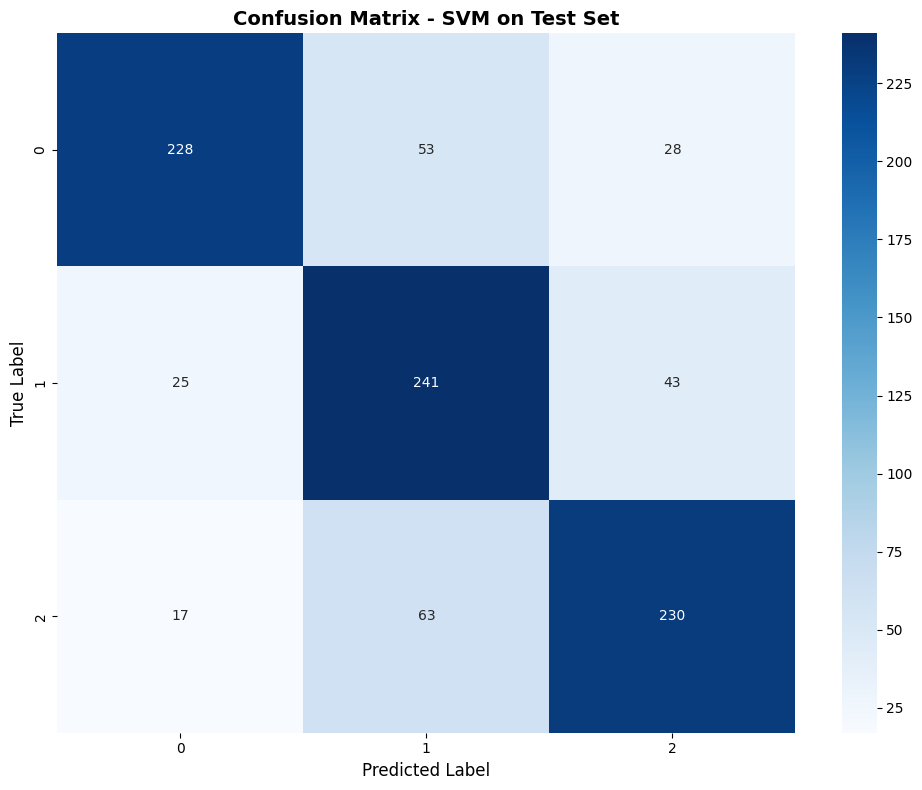


✅ Analysis complete!


In [31]:
# ============================================================================
# EXAMPLE: ANALYZING SVM RESULTS
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Example: How to train and analyze SVM on a train/test split
# (Optional - you've already done cross-validation above)

# Split data for analysis
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Target"])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*70)
print("TRAIN/TEST SPLIT FOR DETAILED ANALYSIS")
print("="*70)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Train SVM
print("\nTraining SVM...")
svm_model = MulticlassSVM(C=1.0, kernel='linear', max_iter=500)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = svm_model.predict(X_train_scaled)
y_pred_test = svm_model.predict(X_test_scaled)

# Metrics
train_acc = np.mean(y_pred_train == y_train)
test_acc = np.mean(y_pred_test == y_test)

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"\nTrain Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Overfitting Gap: {(train_acc - test_acc)*100:.2f}%")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM on Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✅ Analysis complete!")

`Provide your analysis here`